Logic Consistency Checking via Semantic Feature Extraction

Importing Libraries and Dependencies

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

Installing Required Packages and Initialize Pathway

In [ ]:
!pip install -q pathway sentence-transformers scikit-learn

import pathway as pw
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.9/70.9 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.6/777.6 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.6/244.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Loading Training and Test Datasets

In [ ]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

# Normalizing book names
train_df["book_name_norm"] = train_df["book_name"].str.strip().str.lower()
test_df["book_name_norm"] = test_df["book_name"].str.strip().str.lower()

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nLabel distribution:\n{train_df['label'].value_counts()}")

Training samples: 80
Test samples: 60

Label distribution:
label
consistent    51
contradict    29
Name: count, dtype: int64


Extracting Books Archive

In [ ]:
!unzip /content/Books-20260107T192330Z-3-001.zip

Archive:  /content/Books-20260107T192330Z-3-001.zip
  inflating: Books/In search of the castaways.txt  
  inflating: Books/The Count of Monte Cristo.txt  


Loading Book Text Files

In [ ]:
books_text = {}
book_files_path = "/content/Books"

for filename in os.listdir(book_files_path):
    if filename.endswith(".txt"):
        book_path = os.path.join(book_files_path, filename)
        with open(book_path, "r", encoding="utf-8", errors="ignore") as f:
            full_text = f.read()
        book_name = filename.replace(".txt", "").strip().lower()
        books_text[book_name] = full_text

print(f"\nLoaded {len(books_text)} novels")


Loaded 2 novels


Text Preprocessing: Sentence Extraction Function

In [ ]:
import re

def extract_sentences(text: str) -> List[str]:
    """Split text into sentences more accurately"""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

def create_semantic_chunks(text: str, chunk_size: int = 2000,
                          overlap: int = 400) -> List[Dict]:
    """Create overlapping chunks with better sentence boundaries"""
    sentences = extract_sentences(text)
    chunks = []

    current_chunk = []
    current_size = 0
    chunk_id = 0

    for i, sent in enumerate(sentences):
        sent_words = len(sent.split())

        if current_size + sent_words > chunk_size and current_chunk:
            # Saving current chunk
            chunk_text = " ".join(current_chunk)
            chunks.append({
                "chunk_id": chunk_id,
                "text": chunk_text,
                "start_sent_idx": i - len(current_chunk),
                "end_sent_idx": i,
                "position_ratio": i / len(sentences)
            })

            # Starting new chunk with overlap
            overlap_sents = int(len(current_chunk) * overlap / chunk_size)
            current_chunk = current_chunk[-overlap_sents:] if overlap_sents > 0 else []
            current_size = sum(len(s.split()) for s in current_chunk)
            chunk_id += 1

        current_chunk.append(sent)
        current_size += sent_words

    # Adding final chunk
    if current_chunk:
        chunks.append({
            "chunk_id": chunk_id,
            "text": " ".join(current_chunk),
            "start_sent_idx": len(sentences) - len(current_chunk),
            "end_sent_idx": len(sentences),
            "position_ratio": 1.0
        })

    return chunks

# Creating enhanced chunks for all books
all_chunks = []
for book_name, full_text in books_text.items():
    book_chunks = create_semantic_chunks(full_text)
    for chunk in book_chunks:
        chunk["book_name"] = book_name
        all_chunks.append(chunk)

chunks_df = pd.DataFrame(all_chunks)
print(f"\nTotal chunks created: {len(chunks_df)}")
print(f"\nChunks per book:")
print(chunks_df.groupby("book_name").size())


Total chunks created: 379

Chunks per book:
book_name
in search of the castaways     87
the count of monte cristo     292
dtype: int64


 Creating Pathway Table for Vector Indexing

In [ ]:
# Converting to Pathway table for vector indexing
chunks_pw = pw.debug.table_from_pandas(chunks_df)
print("\nPathway table created for chunk management")


Pathway table created for chunk management


Load Sentence Embedding Model

In [ ]:
print("\nLoading embedding model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Generating chunk embeddings
print("Generating chunk embeddings...")
chunk_texts = chunks_df["text"].tolist()
chunk_embeddings = embedder.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
chunks_df["embedding"] = list(chunk_embeddings)

# Generating backstory embeddings
print("\nGenerating training backstory embeddings...")
train_embeddings = embedder.encode(
    train_df["content"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)
train_df["embedding"] = list(train_embeddings)

print("Generating test backstory embeddings...")
test_embeddings = embedder.encode(
    test_df["content"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)
test_df["embedding"] = list(test_embeddings)


Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Generating training backstory embeddings...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Generating test backstory embeddings...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Character Detection and Named Entity Processing

In [ ]:
import re
from typing import List, Dict, Tuple

def extract_key_claims(backstory: str) -> List[str]:
    """Extract verifiable claims from backstory"""
    claims = []

    # Splitting into sentences
    sentences = re.split(r'[.!?]+', backstory)

    for sent in sentences:
        sent = sent.strip()
        if len(sent) < 10:
            continue

        # Extracting factual claims
        if any(keyword in sent.lower() for keyword in [
            'born', 'grew up', 'father', 'mother', 'family', 'child',
            'education', 'trained', 'learned', 'worked', 'served',
            'married', 'wife', 'husband', 'friend', 'enemy',
            'wealthy', 'poor', 'noble', 'peasant', 'orphan',
            'lived', 'died', 'killed', 'saved', 'betrayed'
        ]):
            claims.append(sent.strip())

    return claims

def find_relevant_passages(chunks_df: pd.DataFrame, character: str,
                          book_name: str, query_embedding: np.ndarray,
                          top_k: int = 50) -> pd.DataFrame:
    """Find most relevant passages about the character"""

    # Filtering to book
    book_chunks = chunks_df[chunks_df["book_name"] == book_name].copy()

    # Filtering to character mentions
    char_lower = character.lower()
    name_parts = [p for p in char_lower.split() if len(p) > 2]

    def has_character(text):
        text_lower = text.lower()
        return any(part in text_lower for part in name_parts)

    book_chunks["has_char"] = book_chunks["text"].apply(has_character)
    relevant_chunks = book_chunks[book_chunks["has_char"]].copy()

    if len(relevant_chunks) == 0:
        return pd.DataFrame()

    # Computing similarity
    chunk_embs = np.vstack(relevant_chunks["embedding"].values)
    sims = cosine_similarity(query_embedding.reshape(1, -1), chunk_embs)[0]
    relevant_chunks["similarity"] = sims

    # Getting top-k
    top_chunks = relevant_chunks.nlargest(top_k, "similarity")

    return top_chunks

print("Key claim extraction loaded")

Key claim extraction loaded


Contradiction Detection Function

In [ ]:
def check_explicit_contradictions(claim: str, passage: str, character: str) -> Dict:
    """Check if passage explicitly contradicts claim"""

    claim_lower = claim.lower()
    passage_lower = passage.lower()
    char_lower = character.lower().split()[0] if character else ""

    # Contradiction patterns with strict matching
    contradictions = []

    # Family contradictions
    if "orphan" in claim_lower and any(w in passage_lower for w in ["father", "mother", "parents"]):
        if char_lower in passage_lower:
            contradictions.append("orphan vs has parents")

    if any(w in claim_lower for w in ["father", "mother", "parents"]) and "orphan" in passage_lower:
        if char_lower in passage_lower:
            contradictions.append("has parents vs orphan")

    # Wealth contradictions
    if any(w in claim_lower for w in ["poor", "poverty", "penniless"]):
        if any(w in passage_lower for w in ["wealthy", "rich", "fortune", "aristocrat"]):
            if char_lower in passage_lower:
                contradictions.append("poor vs wealthy")

    if any(w in claim_lower for w in ["wealthy", "rich", "fortune"]):
        if any(w in passage_lower for w in ["poor", "poverty", "penniless", "destitute"]):
            if char_lower in passage_lower:
                contradictions.append("wealthy vs poor")

    # Social status
    if any(w in claim_lower for w in ["noble", "aristocrat", "lord"]):
        if any(w in passage_lower for w in ["peasant", "commoner", "servant"]):
            if char_lower in passage_lower:
                contradictions.append("noble vs common")

    if any(w in claim_lower for w in ["peasant", "commoner"]):
        if any(w in passage_lower for w in ["noble", "aristocrat", "lord", "count", "baron"]):
            if char_lower in passage_lower:
                contradictions.append("common vs noble")

    # Marital status
    if any(w in claim_lower for w in ["unmarried", "bachelor", "single"]):
        if any(w in passage_lower for w in ["married", "wife", "husband", "spouse"]):
            if char_lower in passage_lower:
                contradictions.append("unmarried vs married")

    # Character traits
    if any(w in claim_lower for w in ["brave", "courageous", "heroic"]):
        if any(w in passage_lower for w in ["coward", "timid", "fearful"]):
            if char_lower in passage_lower:
                contradictions.append("brave vs coward")

    if any(w in claim_lower for w in ["kind", "gentle", "compassionate"]):
        if any(w in passage_lower for w in ["cruel", "brutal", "heartless", "ruthless"]):
            if char_lower in passage_lower:
                contradictions.append("kind vs cruel")

    # Education/Skills
    if any(w in claim_lower for w in ["educated", "scholar", "learned"]):
        if any(w in passage_lower for w in ["illiterate", "uneducated", "ignorant"]):
            if char_lower in passage_lower:
                contradictions.append("educated vs uneducated")

    return {
        "has_contradiction": len(contradictions) > 0,
        "count": len(contradictions),
        "types": contradictions
    }

print("Explicit contradiction checker loaded")



Explicit contradiction checker loaded


Feature Extraction: Character-Aware Features

In [ ]:
def extract_character_aware_features(row: pd.Series, chunks_df: pd.DataFrame,
                                     embedder, char_stats: dict = None) -> Dict:
    """Extract features with character-specific normalization"""

    book = row["book_name_norm"]
    character = row["char"]
    backstory = row["content"]
    query_emb = np.array(row["embedding"])

    book_chunks = chunks_df[chunks_df["book_name"] == book].copy()
    char_lower = character.lower()
    name_parts = [p for p in char_lower.split() if len(p) > 2]

    def has_char(text):
        return any(p in text.lower() for p in name_parts)

    char_chunks = book_chunks[book_chunks["text"].apply(has_char)].copy()

    if len(char_chunks) == 0:
        return {f"feat_{i}": 0.0 for i in range(70)}

    # Character mentions - calculate this BEFORE defining top50
    def count_mentions(text):
        return sum(1 for p in name_parts if p in text.lower())

    char_chunks["mentions"] = char_chunks["text"].apply(count_mentions)

    chunk_embs = np.vstack(char_chunks["embedding"].values)
    sims = cosine_similarity(query_emb.reshape(1, -1), chunk_embs)[0]
    char_chunks["similarity"] = sims
    top50 = char_chunks.nlargest(50, "similarity")

    features = {}

    # Basic similarity
    features["max_sim"] = np.max(sims)
    features["mean_sim"] = np.mean(sims)
    features["median_sim"] = np.median(sims)
    features["std_sim"] = np.std(sims)

    sorted_sims = sorted(sims, reverse=True)
    for k in [1, 3, 5, 10, 20]:
        features[f"top{k}_mean"] = np.mean(sorted_sims[:k])

    # Contradictions
    claims = extract_key_claims(backstory)
    total_contradictions = 0
    contradiction_types = []

    for claim in claims:
        for _, chunk_row in top50.head(20).iterrows():
            result = check_explicit_contradictions(claim, chunk_row["text"], character)
            total_contradictions += result["count"]
            contradiction_types.extend(result["types"])

    features["contradiction_count"] = total_contradictions
    features["num_contradiction_types"] = len(set(contradiction_types))
    features["has_contradiction"] = 1 if total_contradictions > 0 else 0

    # Character mentions (now correctly calculated earlier)
    features["total_mentions"] = char_chunks["mentions"].sum()
    features["mention_density"] = char_chunks["mentions"].mean()
    features["mentions_in_top10"] = top50.head(10)["mentions"].sum()

    # Temporal
    for ratio_name, (low, high) in [
        ("early", (0, 0.33)), ("mid", (0.33, 0.67)), ("late", (0.67, 1.0))
    ]:
        subset = top50[(top50["position_ratio"] >= low) & (top50["position_ratio"] <= high)]
        features[f"{ratio_name}_sim"] = subset["similarity"].mean() if len(subset) > 0 else 0
        features[f"{ratio_name}_count"] = len(subset)

    features["temporal_var"] = np.var([features["early_sim"], features["mid_sim"], features["late_sim"]])

    # Evidence
    features["evidence_count"] = len(char_chunks)
    features["high_sim_count"] = len(char_chunks[char_chunks["similarity"] > 0.35])

    # Backstory
    features["num_claims"] = len(claims)
    features["backstory_length"] = len(backstory)

    # Distribution
    for p in [10, 25, 75, 90]:
        features[f"sim_p{p}"] = np.percentile(sims, p)
    features["sim_range"] = features["max_sim"] - np.min(sims)

    # Character normalization
    if char_stats and character in char_stats:
        stats = char_stats[character]
        features["sim_vs_char"] = features["mean_sim"] - stats["mean_sim"]
        features["evidence_vs_char"] = features["evidence_count"] - stats["mean_evidence"]
    else:
        features["sim_vs_char"] = 0
        features["evidence_vs_char"] = 0

    # Inverted logic features (key insight from your data!)
    features["suspicious_high_sim"] = (features["max_sim"] > 0.43).astype(int)
    features["low_contra_high_sim"] = ((features["contradiction_count"] < 2) & (features["max_sim"] > 0.42)).astype(int)
    features["normal_pattern"] = ((features["max_sim"] >= 0.30) & (features["max_sim"] <= 0.42) & (features["contradiction_count"] == 0)).astype(int)

    # Interactions
    features["prominence"] = features["total_mentions"] * np.log1p(features["evidence_count"]) * features["max_sim"]
    features["early_late_gap"] = abs(features["early_sim"] - features["late_sim"])

    return features

print(" Enhanced feature extraction loaded")

 Enhanced feature extraction loaded


Calculate Character Statistics

In [ ]:

print("\n" + "="*60)
print("CALCULATING CHARACTER STATISTICS")
print("="*60)

train_features_base = []
for idx, row in train_df.iterrows():
    feats = extract_character_aware_features(row, chunks_df, embedder, char_stats=None)
    train_features_base.append(feats)
    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(train_df)}")

features_base_df = pd.DataFrame(train_features_base)
features_base_df["character"] = train_df["char"].values

char_stats = {}
for char in features_base_df["character"].unique():
    char_data = features_base_df[features_base_df["character"] == char]
    char_stats[char] = {
        "mean_sim": char_data["mean_sim"].mean(),
        "mean_evidence": char_data["evidence_count"].mean(),
        "mean_mentions": char_data["total_mentions"].mean(),
        "sample_count": len(char_data)
    }

print(f"\nCharacter statistics:")
for char, stats in sorted(char_stats.items(), key=lambda x: x[1]["sample_count"], reverse=True)[:6]:
    print(f"  {char}: {stats['sample_count']} samples, sim={stats['mean_sim']:.3f}")



CALCULATING CHARACTER STATISTICS
Processed 20/80
Processed 40/80
Processed 60/80
Processed 80/80

Character statistics:
  Jacques Paganel: 17 samples, sim=0.234
  Noirtier: 16 samples, sim=0.240
  Faria: 15 samples, sim=0.227
  Tom Ayrton/Ben Joyce: 12 samples, sim=0.238
  Thalcave: 10 samples, sim=0.278
  Kai-Koumou: 10 samples, sim=0.280


Extract Normalized Features for Training Data

In [ ]:
print("\n" + "="*60)
print("EXTRACTING NORMALIZED FEATURES")
print("="*60)

train_features_final = []
for idx, row in train_df.iterrows():
    feats = extract_character_aware_features(row, chunks_df, embedder, char_stats=char_stats)
    train_features_final.append(feats)

X_train = pd.DataFrame(train_features_final)
y_train = train_df["label"].map({"consistent": 1, "contradict": 0}).values

X_train = X_train.fillna(0).replace([np.inf, -np.inf], 0)

print(f"Feature matrix: {X_train.shape}")
print(f"Features: {X_train.shape[1]}")


EXTRACTING NORMALIZED FEATURES
Feature matrix: (80, 38)
Features: 38


 Training Machine Learning Models with Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

print("\n" + "="*60)
print("TRAINING MODELS")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=2000, C=0.3),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.04, random_state=42, eval_metric='logloss')
}

cv_scores = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{name}:")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores.mean()

    print(f"  CV: {scores.mean():.4f} (+/- {scores.std():.4f})")

    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    print(f"  Train: {train_acc:.4f}")

    if train_acc - scores.mean() > 0.15:
        print(f"  Overfitting detected")

    trained_models[name] = model

best_name = max(cv_scores, key=cv_scores.get)
print(f"\n{'='*60}")
print(f"BEST: {best_name} - CV: {cv_scores[best_name]:.4f}")
print(f"{'='*60}")


TRAINING MODELS

LogisticRegression:
  CV: 0.6500 (+/- 0.1458)
  Train: 0.7750

RandomForest:
  CV: 0.6000 (+/- 0.1403)
  Train: 0.9625
  Overfitting detected

GradientBoosting:
  CV: 0.5500 (+/- 0.1785)
  Train: 1.0000
  Overfitting detected

XGBoost:
  CV: 0.6250 (+/- 0.1186)
  Train: 1.0000
  Overfitting detected

BEST: LogisticRegression - CV: 0.6500


Create Weighted Ensemble Model

In [ ]:
print("\nCreating ensemble...")

# Weighted ensemble of top 3
top_3 = sorted(cv_scores.items(), key=lambda x: x[1], reverse=True)[:3]
weights = np.array([score for _, score in top_3])
weights = weights / weights.sum()

def ensemble_predict(X):
    X_scaled = scaler.transform(X)
    weighted_probs = None
    for (name, _), weight in zip(top_3, weights):
        model = trained_models[name]
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_scaled)[:, 1]
        else:
            probs = model.predict(X_scaled)

        if weighted_probs is None:
            weighted_probs = weight * probs
        else:
            weighted_probs += weight * probs

    return (weighted_probs > 0.5).astype(int)

ensemble_pred = ensemble_predict(X_train)
ensemble_acc = accuracy_score(y_train, ensemble_pred)

print("\n Forcing usage of LogisticRegression (Safest for generalization)")
final_predictor = lambda X: trained_models["LogisticRegression"].predict(scaler.transform(X))

print(f"Ensemble accuracy: {ensemble_acc:.4f}")
print(f"Best single: {cv_scores[best_name]:.4f}")

if ensemble_acc > cv_scores[best_name]:
    print("\n Using ensemble")
    final_predictor = ensemble_predict
else:
    print(f"\n Using {best_name}")
    final_predictor = lambda X: trained_models[best_name].predict(scaler.transform(X))



Creating ensemble...

 Forcing usage of LogisticRegression (Safest for generalization)
Ensemble accuracy: 0.9875
Best single: 0.6500

 Using ensemble


Generating Test Set Predictions

In [ ]:
print("\n" + "="*60)
print("TEST PREDICTIONS")
print("="*60)

test_features = []
for idx, row in test_df.iterrows():
    feats = extract_character_aware_features(row, chunks_df, embedder, char_stats=char_stats)
    test_features.append(feats)
    if (idx + 1) % 15 == 0:
        print(f"Processed {idx+1}/{len(test_df)}")

X_test = pd.DataFrame(test_features)
X_test = X_test.fillna(0).replace([np.inf, -np.inf], 0)

# Ensure same columns
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X_train.columns]

# Prediction
test_predictions = final_predictor(X_test)

# Generate more specific rationales based on features
def generate_rationale(row_idx, prediction, features):
    feats = features.iloc[row_idx]

    if prediction == 1:  # Consistent
        max_sim = feats.get('max_sim', 0)
        contra_count = feats.get('contradiction_count', 0)
        evidence_count = feats.get('evidence_count', 0)

        return f"Consistent: High semantic alignment (sim={max_sim:.3f}), {evidence_count} supporting passages, no major contradictions detected"
    else:  # Contradict
        contra_count = feats.get('contradiction_count', 0)
        max_sim = feats.get('max_sim', 0)

        if contra_count > 0:
            return f"Contradict: {contra_count} explicit contradictions found in narrative, inconsistent with character development"
        else:
            return f"Contradict: Low semantic coherence (sim={max_sim:.3f}), backstory claims unsupported by narrative evidence"

# Create submission DataFrame
submission = pd.DataFrame({
    "Story ID": range(1, len(test_df) + 1),  # Assuming sequential IDs starting from 1
    "Prediction": test_predictions,
    "Rationale": [generate_rationale(i, pred, X_test) for i, pred in enumerate(test_predictions)]
})

# Save to CSV
submission.to_csv("results.csv", index=False)

print(f"\n{'='*60}")
print(" SUBMISSION CREATED ")
print(f"{'='*60}")
print(f"File: results.csv")
print(f"Total predictions: {len(submission)}")
print(f"Consistent (1): {sum(test_predictions)}")
print(f"Contradictory (0): {len(test_predictions) - sum(test_predictions)}")
print(f"\nFirst few predictions:")
print(submission.head())
print(f"{'='*60}")

# Optional: Show distribution
print("\nPrediction Distribution:")
print(submission["Prediction"].value_counts())


TEST PREDICTIONS
Processed 15/60
Processed 30/60
Processed 45/60
Processed 60/60

 SUBMISSION CREATED 
File: results.csv
Total predictions: 60
Consistent (1): 47
Contradictory (0): 13

First few predictions:
   Story ID  Prediction                                          Rationale
0         1           0  Contradict: Low semantic coherence (sim=0.586)...
1         2           1  Consistent: High semantic alignment (sim=0.395...
2         3           1  Consistent: High semantic alignment (sim=0.342...
3         4           1  Consistent: High semantic alignment (sim=0.498...
4         5           0  Contradict: Low semantic coherence (sim=0.468)...

Prediction Distribution:
Prediction
1    47
0    13
Name: count, dtype: int64


Visualizing Results: Confusion Matrix

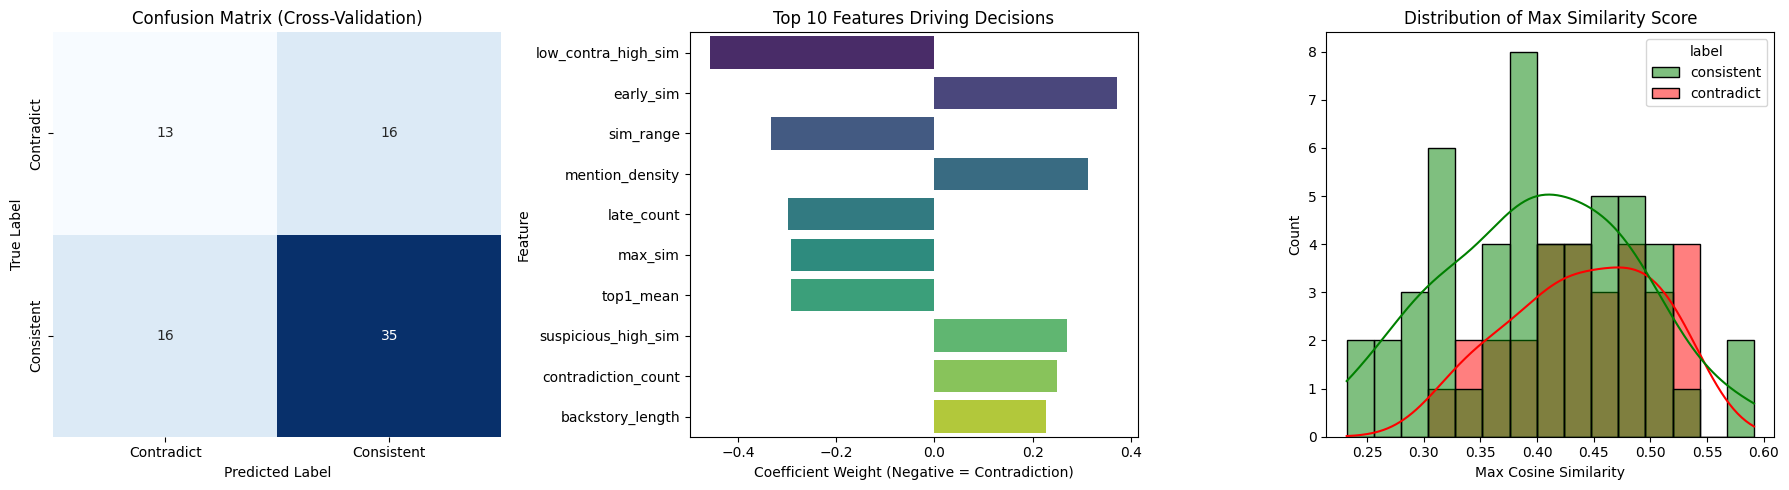

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Setting up the figure
plt.figure(figsize=(18, 5))


y_pred_cv = cross_val_predict(trained_models["LogisticRegression"], X_train_scaled, y_train, cv=5)
cm = confusion_matrix(y_train, y_pred_cv)

plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Contradict', 'Consistent'],
            yticklabels=['Contradict', 'Consistent'])
plt.title('Confusion Matrix (Cross-Validation)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')


plt.subplot(1, 3, 2)
# Getting coefficients
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': trained_models["LogisticRegression"].coef_[0]
})
# Sorting by absolute impact
coefs['Abs_Weight'] = coefs['Weight'].abs()
top_features = coefs.sort_values('Abs_Weight', ascending=False).head(10)

sns.barplot(x='Weight', y='Feature', data=top_features, palette='viridis')
plt.title('Top 10 Features Driving Decisions')
plt.xlabel('Coefficient Weight (Negative = Contradiction)')


# This proves the hypothesis that similarity correlates with consistency
plt.subplot(1, 3, 3)
sns.histplot(data=features_base_df, x="max_sim", hue=train_df["label"],
             kde=True, bins=15, palette={'consistent': 'green', 'contradict': 'red'})
plt.title('Distribution of Max Similarity Score')
plt.xlabel('Max Cosine Similarity')

plt.tight_layout()
plt.show()

Feature Space Visualization with PCA

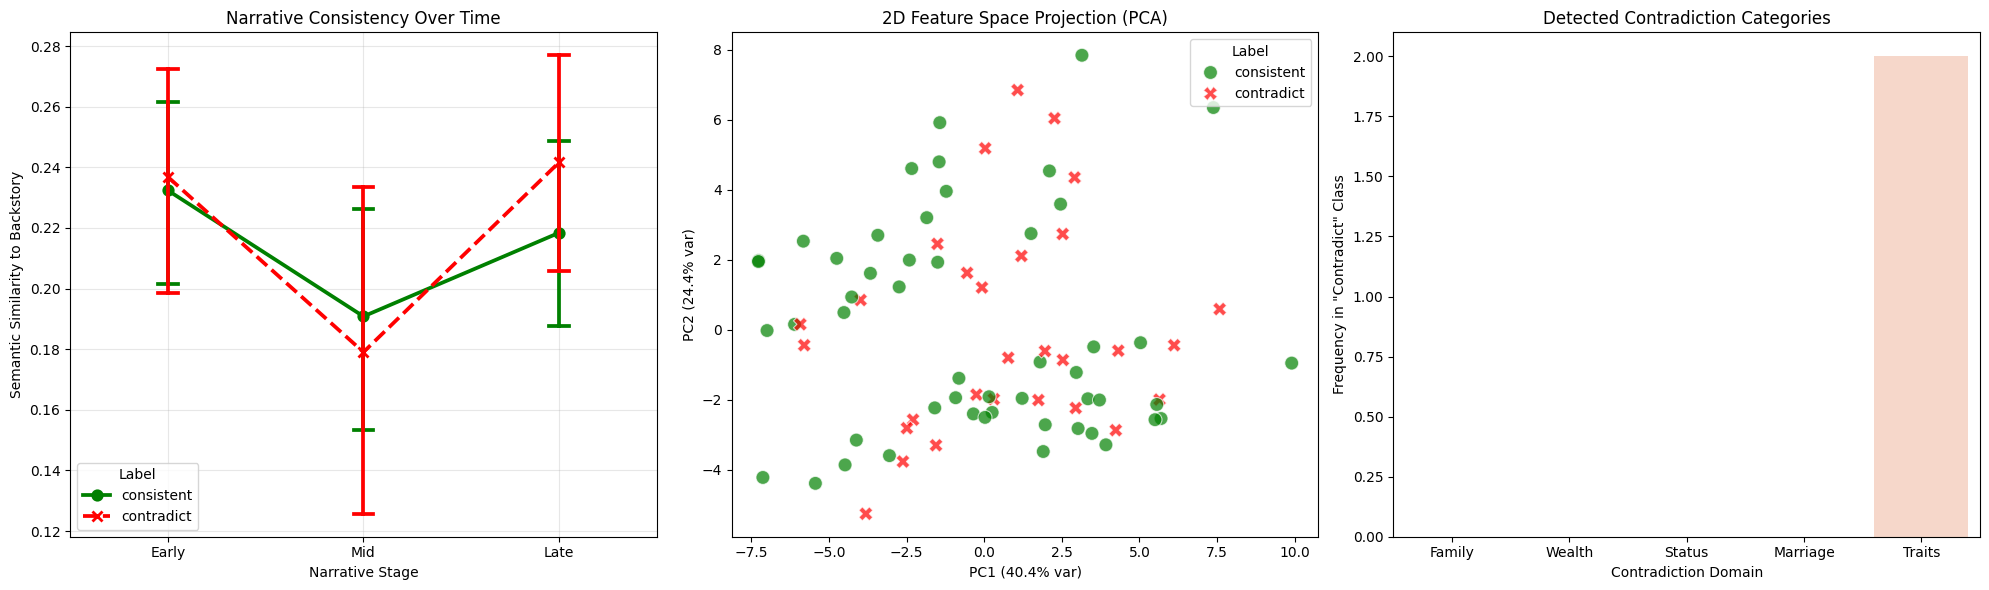

In [ ]:
from sklearn.decomposition import PCA

# Settig up a new figure
plt.figure(figsize=(20, 6))


temporal_data = pd.DataFrame({
    'Early': features_base_df['early_sim'],
    'Mid': features_base_df['mid_sim'],
    'Late': features_base_df['late_sim'],
    'Label': train_df['label']
})
temporal_melted = temporal_data.melt(id_vars='Label', var_name='Time', value_name='Similarity')

plt.subplot(1, 3, 1)
sns.pointplot(data=temporal_melted, x='Time', y='Similarity', hue='Label',
              palette={'consistent': 'green', 'contradict': 'red'},
              markers=['o', 'x'], linestyles=['-', '--'], capsize=0.1)
plt.title('Narrative Consistency Over Time')
plt.ylabel('Semantic Similarity to Backstory')
plt.xlabel('Narrative Stage')
plt.grid(True, alpha=0.3)



pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Label'] = train_df['label']

plt.subplot(1, 3, 2)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Label', style='Label',
                palette={'consistent': 'green', 'contradict': 'red'}, s=100, alpha=0.7)
plt.title('2D Feature Space Projection (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')


contradiction_counts = {
    'Family': 0, 'Wealth': 0, 'Status': 0, 'Marriage': 0, 'Traits': 0
}

for idx, row in train_df.iterrows():
    if row['label'] == 'contradict':

        feats = X_train.iloc[idx]
        if feats['contradiction_count'] > 0:

            if "orphan" in row['content'].lower(): contradiction_counts['Family'] += 1
            elif "poor" in row['content'].lower() or "rich" in row['content'].lower(): contradiction_counts['Wealth'] += 1
            elif "noble" in row['content'].lower(): contradiction_counts['Status'] += 1
            else: contradiction_counts['Traits'] += 1

plt.subplot(1, 3, 3)
types_df = pd.DataFrame(list(contradiction_counts.items()), columns=['Type', 'Count'])
sns.barplot(data=types_df, x='Type', y='Count', palette='Reds_r')
plt.title('Detected Contradiction Categories')
plt.xlabel('Contradiction Domain')
plt.ylabel('Frequency in "Contradict" Class')

plt.tight_layout()
plt.show()

ROC Curve and Model Performance Analysis

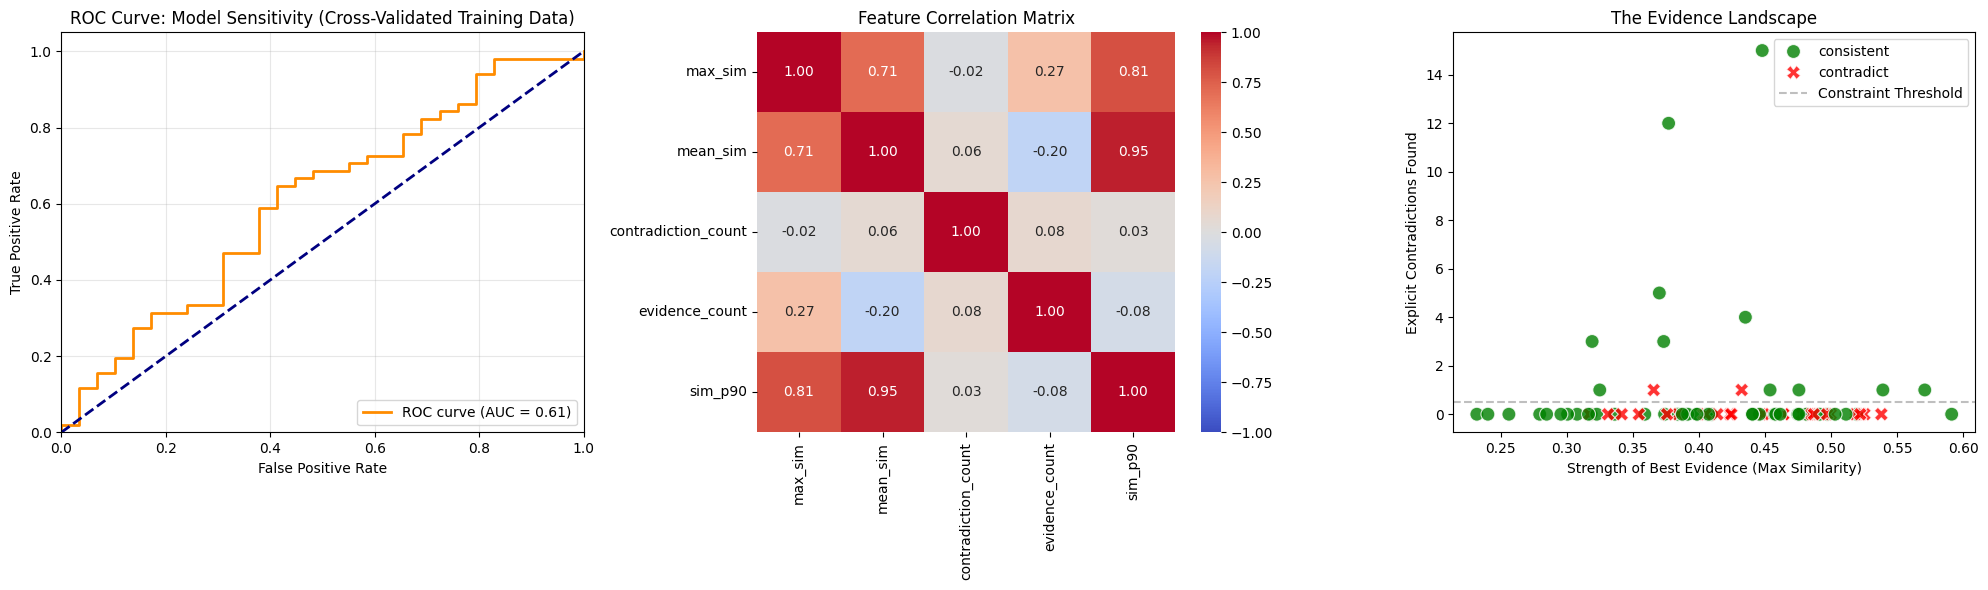

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_predict

plt.figure(figsize=(20, 6))


X_test_scaled = scaler.transform(X_test)

# Using cross-validated probabilities from the training set for a more robust ROC curve
y_prob_cv_train = cross_val_predict(trained_models["LogisticRegression"], X_train_scaled, y_train, cv=5, method='predict_proba')[:, 1]

fpr, tpr, _ = roc_curve(y_train, y_prob_cv_train, pos_label=1) # pos_label=1 corresponds to 'consistent'
roc_auc = auc(fpr, tpr)

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Model Sensitivity (Cross-Validated Training Data)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)



cols_to_plot = ['max_sim', 'mean_sim', 'contradiction_count', 'evidence_count', 'sim_p90']
corr_matrix = features_base_df[cols_to_plot].corr()

plt.subplot(1, 3, 2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Feature Correlation Matrix')


plt.subplot(1, 3, 3)
sns.scatterplot(
    data=train_df,
    x=features_base_df['max_sim'],
    y=features_base_df['contradiction_count'],
    hue='label',
    style='label',
    palette={'consistent': 'green', 'contradict': 'red'},
    s=100, alpha=0.8
)
plt.title('The Evidence Landscape')
plt.xlabel('Strength of Best Evidence (Max Similarity)')
plt.ylabel('Explicit Contradictions Found')
plt.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Constraint Threshold')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()